# Question 9

(a) grabCut to segment the image

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


image = cv2.imread('daisy.jpg')
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


In [19]:
# Create initial mask
mask = np.zeros(image.shape[:2], np.uint8)

# Models used by grabCut algorithm
bgdModel = np.zeros((1, 65), np.float64)
fgdModel = np.zeros((1, 65), np.float64)

# Rectangle containing the flower 
rect = (36, 36, image.shape[1]-100, image.shape[0]-100)

# Apply grabCut
cv2.grabCut(image_rgb, mask, rect, bgdModel, fgdModel, 5, cv2.GC_INIT_WITH_RECT)

# Create final segmentation mask
final_mask = np.where((mask == 2) | (mask == 0), 0, 1).astype('uint8')

# Foreground and background
foreground = image_rgb * final_mask[:, :, np.newaxis]
background = image_rgb * (1 - final_mask[:, :, np.newaxis])

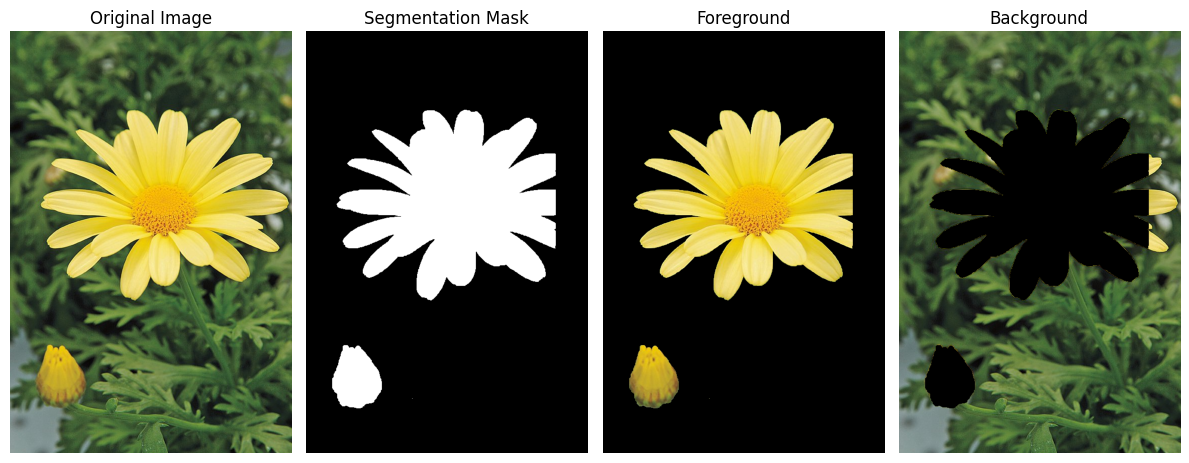

In [20]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 4, 1)
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(final_mask, cmap='gray')
plt.title("Segmentation Mask")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(foreground)
plt.title("Foreground")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(background)
plt.title("Background")
plt.axis("off")

plt.tight_layout()
plt.show()

(b) enhanced image with a substantially blurred background

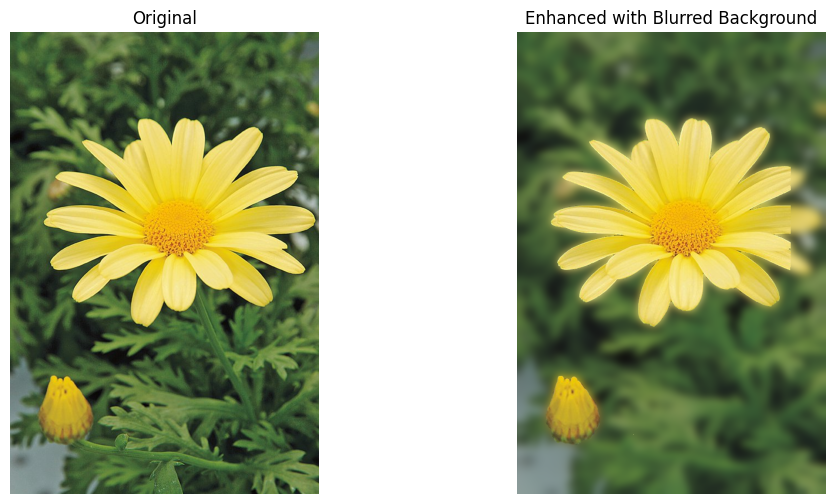

In [21]:
# Heavy Gaussian blur for background
blurred_background = cv2.GaussianBlur(image_rgb, (51, 51), 0)

# Combine sharp foreground with blurred background
enhanced = blurred_background.copy()
enhanced[final_mask == 1] = image_rgb[final_mask == 1]

# Display original and enhanced
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1), plt.imshow(image_rgb), plt.title("Original"), plt.axis("off")
plt.subplot(1, 2, 2), plt.imshow(enhanced), plt.title("Enhanced with Blurred Background"), plt.axis("off")
plt.show()


(c) Why is the background just beyond the edge of the flower quite dark in the enhanced image?

**Answer:**  

**GrabCut’s segmentation mask is not perfect.Around edges, it sometimes classifies thin boundary regions as background instead of foreground.**

**Pixels near the edge of the flower are often dark or shadowed in the original image.When the background is heavily blurred, the dark colors from the background “bleed” into the boundary area, making it look even darker.**